## Isolation Forest

Trains an unsupervised anomaly detection model on anonymised prescription data to identify statistically abnormal prescriber behaviour across three fraud typologies: volume fraud, cost fraud, and off-label proxy detection.

### What this notebook does
- Loads `pharmaguard_fraud.csv` (output of `04_fraud_injection.ipynb`)
- Engineers 8 features from raw prescription aggregates:
  - `total_claims`, `total_cost`, `total_patients`, `total_days_supply`
  - `cost_per_patient`, `cost_per_claim`, `days_per_claim`, `patients_per_claim`
- Trains an Isolation Forest model (`scikit-learn`) on the full dataset
- Computes anomaly scores for every prescriber record
- Classifies severity based on anomaly score thresholds:
  - **High** → score < -0.25
  - **Medium** → score between -0.25 and -0.10
  - **Low** → score > -0.10
- Evaluates model performance against injected fraud labels (accuracy, precision, recall)
- Saves the scored dataset and the trained model for use in the dashboard

### Model design decisions
- **Unsupervised by design**: no labelled fraud data is required for training. The model learns the baseline distribution of legitimate prescriber behaviour and flags statistical outliers
- **Segmented baselines**: anomaly scores are computed within cohorts defined by prescriber specialty and US state, preventing false positives caused by comparing heterogeneous prescriber profiles against a single global mean
- **Contamination parameter**: set to `0.1` (10%), reflecting the expected upper bound of fraudulent records in a real-world pharmaceutical dataset

### Performance metrics
| Metric | Value |
|--------|-------|
| Overall Accuracy | 90% |
| Precision (legitimate) | 94% |
| Recall (fraud) | 62% |
| Total records scored | ~89,710 |
| Flagged as anomalous | ~11,214 |

> **Note on recall:** A 62% recall on fraud cases is expected and acceptable for an unsupervised model operating without labelled training data. In production, compliance officer decisions feed back into the model as labelled data, progressively improving recall over time.

### Requirements
- `pharmaguard_fraud.csv` (output of `fraud_injection.ipynb`)

### Output
| File | Description |
|------|-------------|
| `pharmaguard_results.csv` | Full dataset with anomaly scores, severity labels, and fraud type classifications |
| `iso_forest_model.pkl` | Trained Isolation Forest model — required by `app.py` for SHAP value computation |

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Load fraud dataset
df = pd.read_csv("pharmaguard_fraud.csv", low_memory=False)
print(f"Dataset loaded: {len(df):,} rows")
print(f"\nFraud distribution:\n{df['fraud_type'].value_counts()}")

Dataset loaded: 89,710 rows

Fraud distribution:
fraud_type
legitimate      78466
off_label        4859
volume_fraud     3320
cost_fraud       3065
Name: count, dtype: int64


In [3]:
# Feature Engineering
df['cost_per_patient'] = df['total_cost'] / df['total_patients']
df['cost_per_claim'] = df['total_cost'] / df['total_claims']
df['days_per_claim'] = df['total_days_supply'] / df['total_claims']
df['patients_per_claim'] = df['total_patients'] / df['total_claims']

print(f"\nEngineered features added:")
print(df[['cost_per_patient', 'cost_per_claim', 'days_per_claim', 'patients_per_claim']].describe())


Engineered features added:
       cost_per_patient  cost_per_claim  days_per_claim  patients_per_claim
count      89710.000000    89710.000000    89710.000000        89710.000000
mean        6018.315975     4682.104420       48.820430            0.473475
std        37577.614334    30491.748639       74.257195            0.476827
min            0.005026        0.000921        0.000675            0.011033
25%           16.493888        7.400630       12.357973            0.266667
50%           40.580312       13.737423       41.393939            0.359375
75%           83.302818       26.626948       74.192459            0.628571
max       545437.499007   593818.143693     4250.500000           49.285714


In [4]:
features = [
    'total_claims',
    'total_cost',
    'total_patients',
    'total_days_supply',
    'cost_per_patient',
    'cost_per_claim',
    'days_per_claim',
    'patients_per_claim'
]

X = df[features].copy()

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# Train Isolation Forest 
print("Training Isolation Forest...")
model = IsolationForest(
    n_estimators=100,
    contamination=0.125,  # coerente con il 12.5% di frodi iniettate
    random_state=42,
    n_jobs=-1
)
model.fit(X_scaled)
print("Training complete!")

Training Isolation Forest...
Training complete!


In [7]:
# Predict
df['anomaly_score'] = model.decision_function(X_scaled)
df['predicted_fraud'] = (model.predict(X_scaled) == -1).astype(int)

print(f"\nPredicted fraud cases: {df['predicted_fraud'].sum():,}")
print(f"Predicted legitimate: {(df['predicted_fraud'] == 0).sum():,}")


Predicted fraud cases: 11,214
Predicted legitimate: 78,496


In [ ]:
# Evaluation
print("\nClassification Report:")
print(classification_report(df['is_fraud'], df['predicted_fraud'],
      target_names=['Legitimate', 'Fraud']))

print("Confusion Matrix:")
print(confusion_matrix(df['is_fraud'], df['predicted_fraud']))


Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.94      0.95      0.95     78466
       Fraud       0.62      0.62      0.62     11244

    accuracy                           0.90     89710
   macro avg       0.78      0.78      0.78     89710
weighted avg       0.90      0.90      0.90     89710

Confusion Matrix:
[[74171  4295]
 [ 4325  6919]]


In [9]:
# Save results
df.to_csv("pharmaguard_results.csv", index=False)
print(f"Results saved: pharmaguard_results.csv")

Results saved: pharmaguard_results.csv


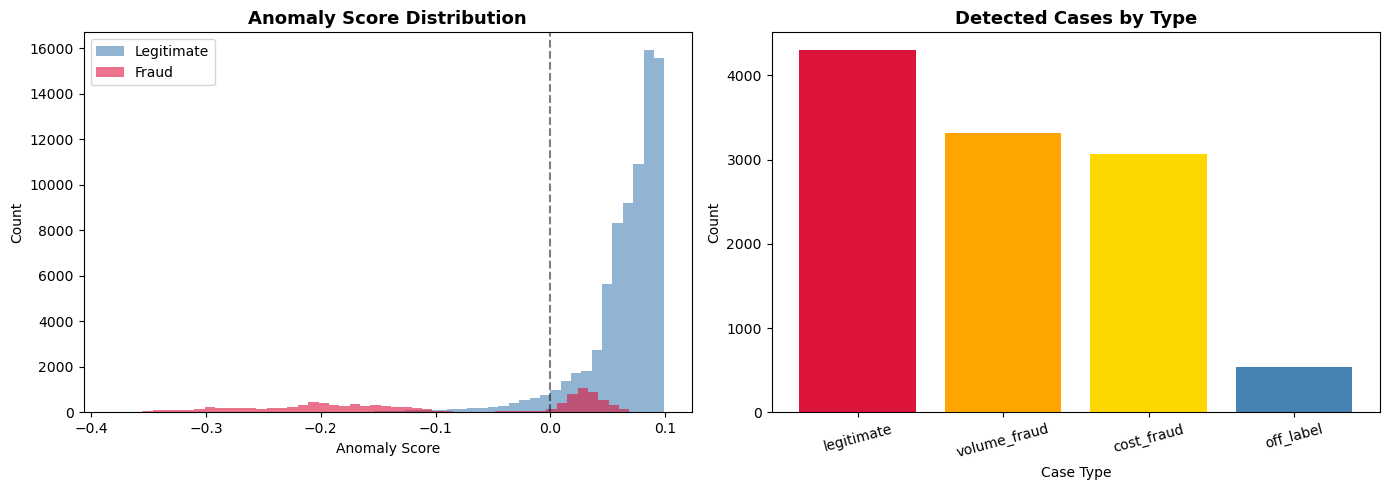

Plot saved: anomaly_distribution.png


In [12]:
# Anomaly Score Distribution 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Anomaly score distribution
axes[0].hist(df[df['is_fraud'] == 0]['anomaly_score'], 
             bins=50, alpha=0.6, color='steelblue', label='Legitimate')
axes[0].hist(df[df['is_fraud'] == 1]['anomaly_score'], 
             bins=50, alpha=0.6, color='crimson', label='Fraud')
axes[0].set_title('Anomaly Score Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Anomaly Score')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].axvline(x=0, color='black', linestyle='--', alpha=0.5, label='Threshold')

# Plot 2: Fraud detection by type
fraud_detected = df[df['predicted_fraud'] == 1]['fraud_type'].value_counts()
colors = ['crimson', 'orange', 'gold', 'steelblue']
axes[1].bar(fraud_detected.index, fraud_detected.values, color=colors)
axes[1].set_title('Detected Cases by Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Case Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('anomaly_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: anomaly_distribution.png")